In [2]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import sys
from pathlib import Path

# Add the project root (ml_laboratory) to Python's search path
sys.path.append(str(Path().resolve().parent))
from utils import (
    eda_tabular
)
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

print("Imported")

Imported


In [3]:
dataset_path = Path("../datasets/English/Hnd/Img/")

print("Dataset exists:", dataset_path.exists())

Dataset exists: True


In [4]:
classes = sorted([folder.name for folder in dataset_path.iterdir() if folder.is_dir()])

print("Number of classes:", len(classes))
print("Classes:", classes)

Number of classes: 62
Classes: ['Sample001', 'Sample002', 'Sample003', 'Sample004', 'Sample005', 'Sample006', 'Sample007', 'Sample008', 'Sample009', 'Sample010', 'Sample011', 'Sample012', 'Sample013', 'Sample014', 'Sample015', 'Sample016', 'Sample017', 'Sample018', 'Sample019', 'Sample020', 'Sample021', 'Sample022', 'Sample023', 'Sample024', 'Sample025', 'Sample026', 'Sample027', 'Sample028', 'Sample029', 'Sample030', 'Sample031', 'Sample032', 'Sample033', 'Sample034', 'Sample035', 'Sample036', 'Sample037', 'Sample038', 'Sample039', 'Sample040', 'Sample041', 'Sample042', 'Sample043', 'Sample044', 'Sample045', 'Sample046', 'Sample047', 'Sample048', 'Sample049', 'Sample050', 'Sample051', 'Sample052', 'Sample053', 'Sample054', 'Sample055', 'Sample056', 'Sample057', 'Sample058', 'Sample059', 'Sample060', 'Sample061', 'Sample062']


In [6]:
total = sum(1 for class_name in classes for f in (dataset_path / class_name).glob("*.png"))

print("PNG files:", total)

PNG files: 3410


In [9]:
images = []
labels = []

image_size = (28, 28)

for i, class_name in enumerate(classes):
    class_path = dataset_path / class_name

    for image_file in class_path.glob("*.png"):
        image = Image.open(image_file).convert("L")
        image = image.resize(image_size)

        images.append(np.array(image))
        labels.append(class_name)

print(f"{i + 1}/62 classes loaded")

X = np.array(images, dtype=np.float32)
y = np.array(labels)

print("Image shape:", X.shape)
print("Labels shape:", y.shape)

62/62 classes loaded
Image shape: (3410, 28, 28)
Labels shape: (3410,)


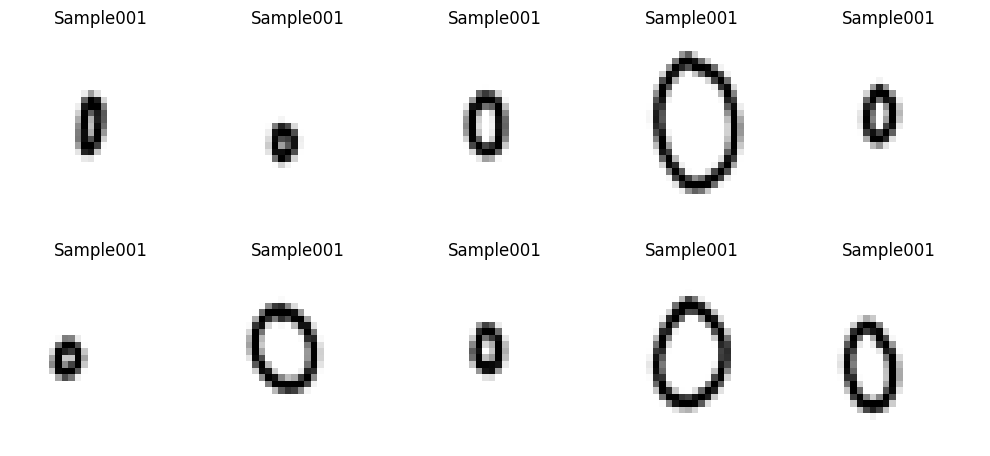

In [10]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i], cmap="gray")
    plt.title(y[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
X = X.reshape(X.shape[0], -1)
X = X / 255.0

print("Feature shape:", X.shape)
print("Minimum:", X.min())
print("Maximum:", X.max())

Feature shape: (3410, 784)
Minimum: 0.0
Maximum: 1.0


In [12]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Number of classes:", len(encoder.classes_))
print("Classes:", encoder.classes_)

Number of classes: 62
Classes: ['Sample001' 'Sample002' 'Sample003' 'Sample004' 'Sample005' 'Sample006'
 'Sample007' 'Sample008' 'Sample009' 'Sample010' 'Sample011' 'Sample012'
 'Sample013' 'Sample014' 'Sample015' 'Sample016' 'Sample017' 'Sample018'
 'Sample019' 'Sample020' 'Sample021' 'Sample022' 'Sample023' 'Sample024'
 'Sample025' 'Sample026' 'Sample027' 'Sample028' 'Sample029' 'Sample030'
 'Sample031' 'Sample032' 'Sample033' 'Sample034' 'Sample035' 'Sample036'
 'Sample037' 'Sample038' 'Sample039' 'Sample040' 'Sample041' 'Sample042'
 'Sample043' 'Sample044' 'Sample045' 'Sample046' 'Sample047' 'Sample048'
 'Sample049' 'Sample050' 'Sample051' 'Sample052' 'Sample053' 'Sample054'
 'Sample055' 'Sample056' 'Sample057' 'Sample058' 'Sample059' 'Sample060'
 'Sample061' 'Sample062']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 2728
Testing samples: 682


In [15]:
class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=20):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0
        self.errors = []

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        self.errors = []

        for epoch in range(self.epochs):
            errors = 0

            for xi, target in zip(X, y):
                prediction = self.predict_one(xi)

                update = self.learning_rate * (target - prediction)

                self.weights += update * xi
                self.bias += update

                if update != 0:
                    errors += 1

            self.errors.append(errors)

        return self

    def predict_one(self, x):
        value = np.dot(x, self.weights) + self.bias
        return 1 if value >= 0 else 0

In [16]:
pla_models = []

for class_label in range(len(encoder.classes_)):
    y_binary = (y_train == class_label).astype(int)

    model = Perceptron(
        learning_rate=0.01,
        epochs=20
    )

    model.fit(X_train, y_binary)
    pla_models.append(model)

print("PLA models trained:", len(pla_models))

PLA models trained: 62


In [17]:
pla_scores = []

for model in pla_models:
    scores = np.dot(X_test, model.weights) + model.bias
    pla_scores.append(scores)

pla_scores = np.array(pla_scores)

pla_predictions = np.argmax(pla_scores, axis=0)

print("PLA predictions:", pla_predictions[:20])

PLA predictions: [25 38 38 22 32 13 38 38 22 38 38 38 38 38 22 42 22 22  9  4]


In [18]:
pla_accuracy = accuracy_score(y_test, pla_predictions)
pla_precision = precision_score(y_test, pla_predictions, average="macro", zero_division=0)
pla_recall = recall_score(y_test, pla_predictions, average="macro", zero_division=0)
pla_f1 = f1_score(y_test, pla_predictions, average="macro", zero_division=0)

print("PLA Accuracy :", round(pla_accuracy, 4))
print("PLA Precision:", round(pla_precision, 4))
print("PLA Recall   :", round(pla_recall, 4))
print("PLA F1-score :", round(pla_f1, 4))

PLA Accuracy : 0.1114
PLA Precision: 0.221
PLA Recall   : 0.1114
PLA F1-score : 0.0869


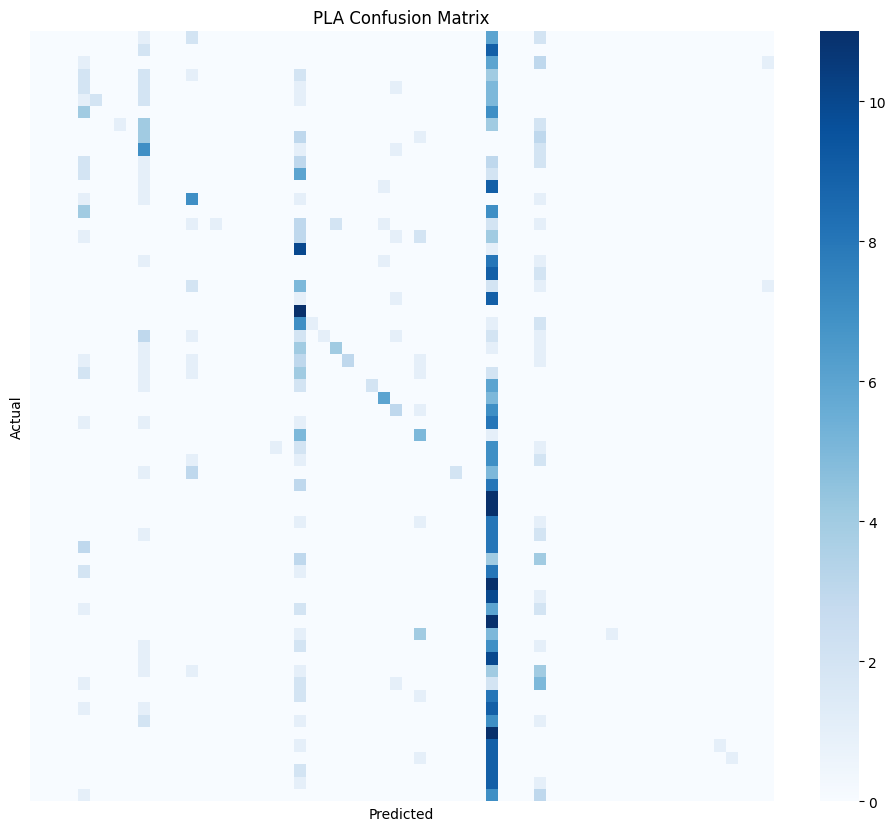

In [19]:
cm_pla = confusion_matrix(y_test, pla_predictions)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm_pla,
    cmap="Blues",
    xticklabels=False,
    yticklabels=False
)

plt.title("PLA Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

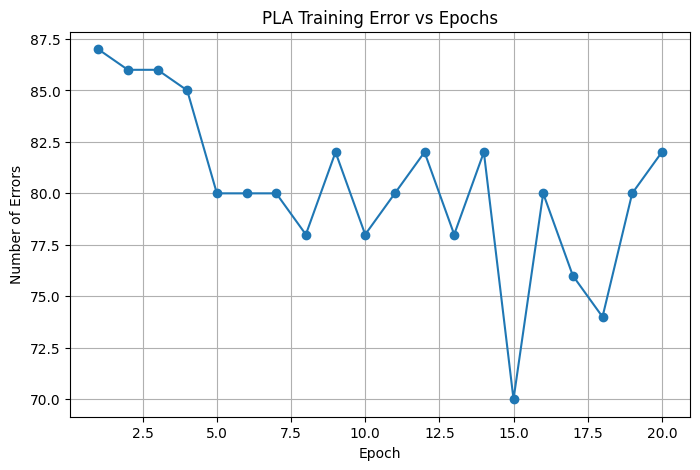

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(pla_models[0].errors) + 1),
    pla_models[0].errors,
    marker="o"
)

plt.title("PLA Training Error vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Number of Errors")
plt.grid(True)

plt.show()

In [21]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    batch_size=32,
    max_iter=50,
    random_state=42
)

mlp.fit(X_train, y_train)

print("MLP training completed")

MLP training completed


In [22]:
mlp_predictions = mlp.predict(X_test)

print("MLP predictions:", mlp_predictions[:20])

MLP predictions: [4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]


In [24]:
mlp_accuracy = accuracy_score(y_test, mlp_predictions)
mlp_precision = precision_score(y_test, mlp_predictions, average="macro")
mlp_recall = recall_score(y_test, mlp_predictions, average="macro")
mlp_f1 = f1_score(y_test, mlp_predictions, average="macro")

print("MLP Accuracy :", round(mlp_accuracy, 4))
print("MLP Precision:", round(mlp_precision, 4))
print("MLP Recall   :", round(mlp_recall, 4))
print("MLP F1-score :", round(mlp_f1, 4))

MLP Accuracy : 0.0161
MLP Precision: 0.0003
MLP Recall   : 0.0161
MLP F1-score : 0.0005


/home/jk/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


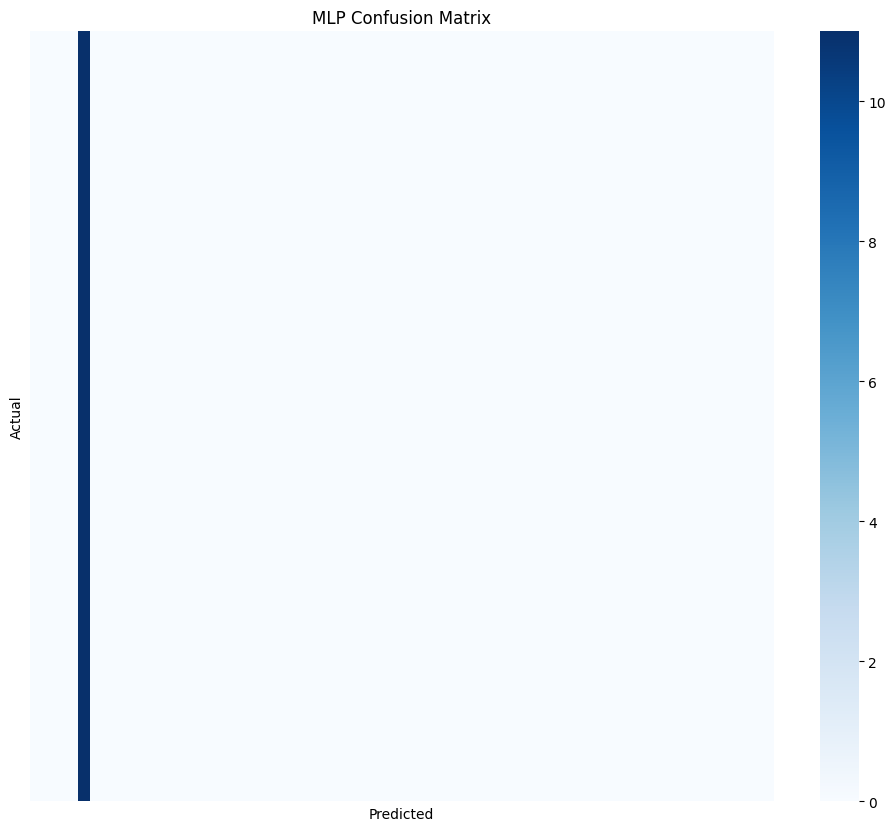

In [25]:
cm_mlp = confusion_matrix(y_test, mlp_predictions)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm_mlp,
    cmap="Blues",
    xticklabels=False,
    yticklabels=False
)

plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
configs = [
    ("relu", "adam", 0.001, 32),
    ("relu", "adam", 0.001, 64),
    ("relu", "sgd", 0.01, 32),
    ("relu", "sgd", 0.01, 64),
    ("tanh", "adam", 0.001, 32),
    ("tanh", "adam", 0.001, 64)
]

tuning_results = []

In [31]:
for activation, optimizer, learning_rate, batch_size in configs:

    print(
        "Testing:",
        activation,
        optimizer,
        learning_rate,
        batch_size
    )

    model = MLPClassifier(
        hidden_layer_sizes=(128,),
        activation=activation,
        solver=optimizer,
        learning_rate_init=learning_rate,
        batch_size=batch_size,
        max_iter=30,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions, average="macro")

    tuning_results.append([
        activation,
        optimizer,
        learning_rate,
        batch_size,
        accuracy,
        f1
    ])

Testing: relu adam 0.001 32


/home/jk/.local/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


AttributeError: 'DataFrame' object has no attribute 'append'

In [32]:
tuning_results = pd.DataFrame(
    tuning_results,
    columns=[
        "Activation",
        "Optimizer",
        "Learning Rate",
        "Batch Size",
        "Accuracy",
        "F1"
    ]
)

print(tuning_results.round(4))

  Activation Optimizer  Learning Rate  Batch Size  Accuracy      F1
0       relu      adam          0.001          32    0.0161  0.0005
1       relu      adam          0.001          64    0.0880  0.0560
2       relu       sgd          0.010          32    0.0161  0.0005
3       relu       sgd          0.010          64    0.1862  0.1561
4       tanh      adam          0.001          32    0.1891  0.1492
5       tanh      adam          0.001          64    0.2786  0.2534


In [33]:
best_config = tuning_results.loc[tuning_results["F1"].idxmax()]

print("Best configuration:")
print(best_config)

Best configuration:
Activation           tanh
Optimizer            adam
Learning Rate       0.001
Batch Size             64
Accuracy         0.278592
F1                0.25344
Name: 5, dtype: object


In [38]:
final_mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation=best_config["Activation"],
    solver=best_config["Optimizer"],
    learning_rate_init=best_config["Learning Rate"],
    batch_size=int(best_config["Batch Size"]),
    max_iter=150,
    random_state=42
)

final_mlp.fit(X_train, y_train)

print("Final MLP training completed")

Final MLP training completed


/home/jk/.local/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


In [39]:
final_predictions = final_mlp.predict(X_test)

final_accuracy = accuracy_score(y_test, final_predictions)
final_precision = precision_score(y_test, final_predictions, average="macro")
final_recall = recall_score(y_test, final_predictions, average="macro")
final_f1 = f1_score(y_test, final_predictions
                    , average="macro")

print("MLP Accuracy :", round(final_accuracy, 4))
print("MLP Precision:", round(final_precision, 4))
print("MLP Recall   :", round(final_recall, 4))
print("MLP F1-score :", round(final_f1, 4))

MLP Accuracy : 0.4238
MLP Precision: 0.4514
MLP Recall   : 0.4238
MLP F1-score : 0.4133


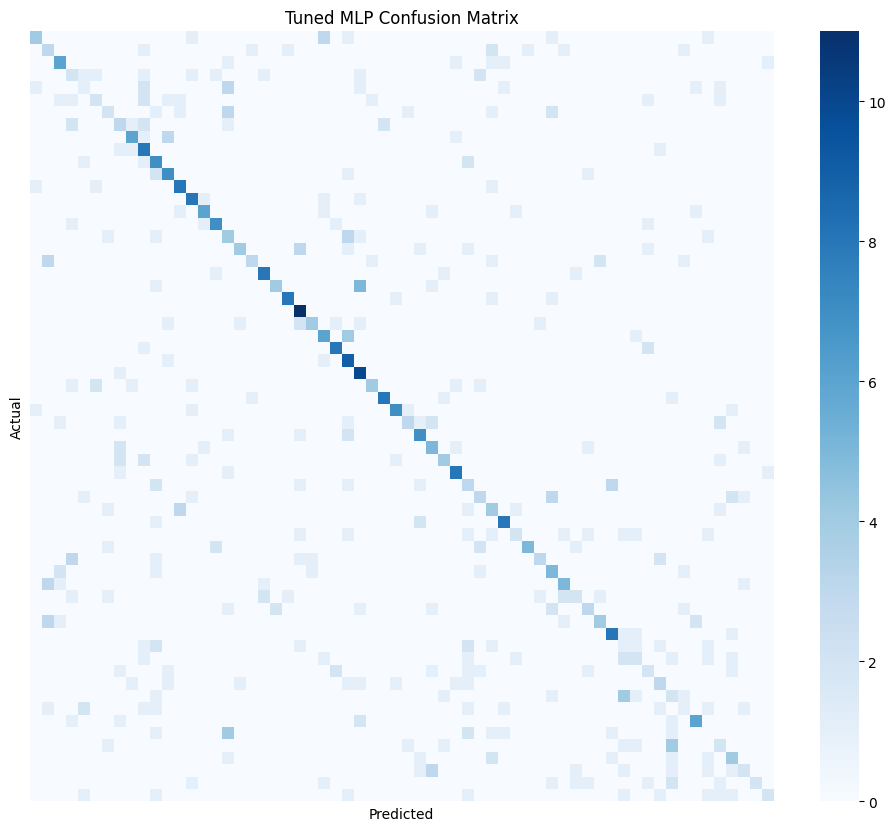

In [40]:
cm_mlp = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm_mlp,
    cmap="Blues",
    xticklabels=False,
    yticklabels=False
)

plt.title("Tuned MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

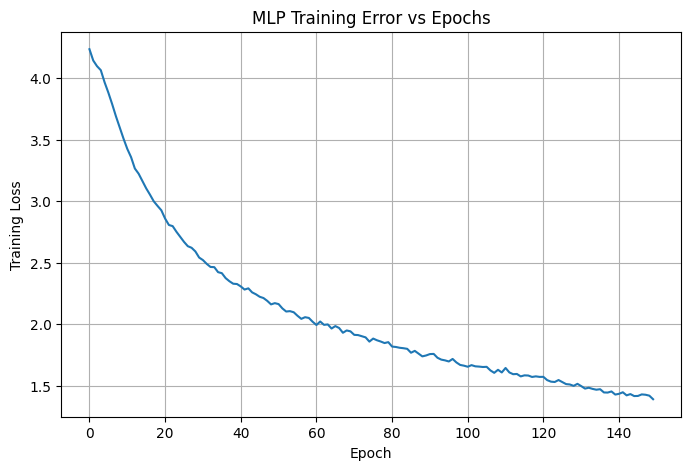

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(final_mlp.loss_curve_)

plt.title("MLP Training Error vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.grid(True)

plt.show()

In [42]:
y_test_binary = label_binarize(
    y_test,
    classes=np.arange(len(encoder.classes_))
)

print("Binary label shape:", y_test_binary.shape)

Binary label shape: (682, 62)


In [43]:
fpr_pla, tpr_pla, _ = roc_curve(
    y_test_binary.ravel(),
    pla_scores.T.ravel()
)

auc_pla = auc(fpr_pla, tpr_pla)

print("PLA ROC-AUC:", round(auc_pla, 4))

PLA ROC-AUC: 0.7517


In [45]:
mlp_probabilities = final_mlp.predict_proba(X_test)

fpr_mlp, tpr_mlp, _ = roc_curve(
    y_test_binary.ravel(),
    mlp_probabilities.ravel()
)

auc_mlp = auc(fpr_mlp, tpr_mlp)

print("MLP ROC-AUC:", round(auc_mlp, 4))

MLP ROC-AUC: 0.9237


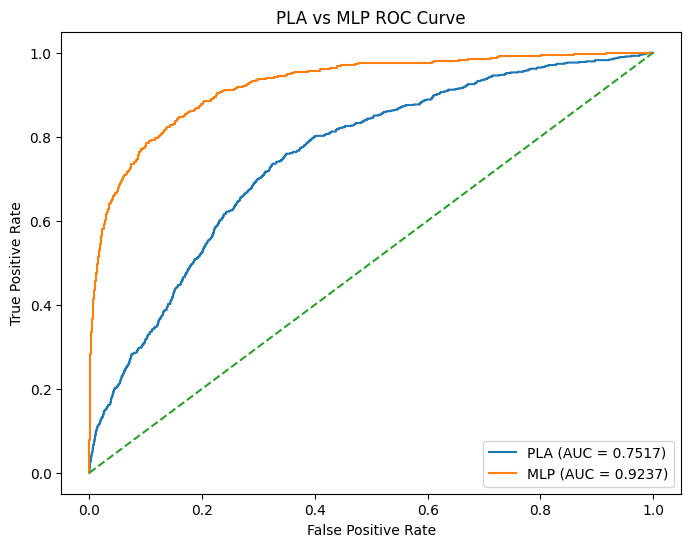

In [46]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_pla,
    tpr_pla,
    label=f"PLA (AUC = {auc_pla:.4f})"
)

plt.plot(
    fpr_mlp,
    tpr_mlp,
    label=f"MLP (AUC = {auc_mlp:.4f})"
)

plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("PLA vs MLP ROC Curve")
plt.legend()

plt.show()

In [47]:
comparison = pd.DataFrame({
    "Model": ["PLA", "MLP"],
    "Accuracy": [pla_accuracy, final_accuracy],
    "Precision": [pla_precision, final_precision],
    "Recall": [pla_recall, final_recall],
    "F1-Score": [pla_f1, final_f1],
    "ROC-AUC": [auc_pla, auc_mlp]
})

print(comparison.round(4))

  Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0   PLA    0.1114     0.2210  0.1114    0.0869   0.7517
1   MLP    0.4238     0.4514  0.4238    0.4133   0.9237


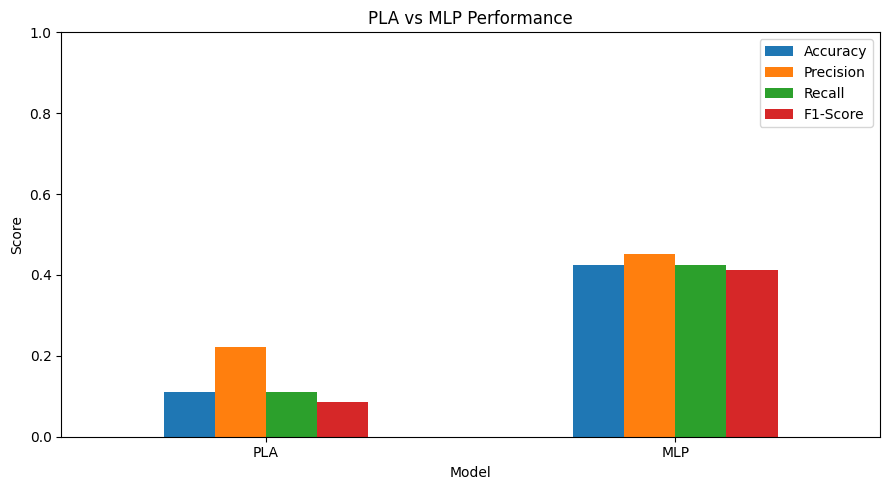

In [48]:
comparison.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("PLA vs MLP Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [49]:
print("MLP Classification Report")

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=encoder.classes_,
        zero_division=0
    )
)

MLP Classification Report
              precision    recall  f1-score   support

   Sample001       0.57      0.36      0.44        11
   Sample002       0.23      0.27      0.25        11
   Sample003       0.50      0.55      0.52        11
   Sample004       0.17      0.18      0.17        11
   Sample005       0.14      0.09      0.11        11
   Sample006       0.33      0.18      0.24        11
   Sample007       0.29      0.18      0.22        11
   Sample008       0.23      0.27      0.25        11
   Sample009       0.60      0.55      0.57        11
   Sample010       0.33      0.73      0.46        11
   Sample011       0.30      0.64      0.41        11
   Sample012       0.47      0.64      0.54        11
   Sample013       0.57      0.73      0.64        11
   Sample014       0.53      0.73      0.62        11
   Sample015       0.67      0.55      0.60        11
   Sample016       0.64      0.64      0.64        11
   Sample017       0.20      0.36      0.26        11
 

In [50]:
print("========== EXPERIMENT 9 RESULTS ==========")

print("\nPLA")
print("Accuracy :", round(pla_accuracy, 4))
print("Precision:", round(pla_precision, 4))
print("Recall   :", round(pla_recall, 4))
print("F1-score :", round(pla_f1, 4))
print("ROC-AUC  :", round(auc_pla, 4))

print("\nBEST MLP CONFIGURATION")
print("Activation   :", best_config["Activation"])
print("Optimizer    :", best_config["Optimizer"])
print("Learning Rate:", best_config["Learning Rate"])
print("Batch Size   :", best_config["Batch Size"])

print("\nMLP")
print("Accuracy :", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall   :", round(final_recall, 4))
print("F1-score :", round(final_f1, 4))
print("ROC-AUC  :", round(auc_mlp, 4))

========== EXPERIMENT 9 RESULTS ==========

PLA
Accuracy : 0.1114
Precision: 0.221
Recall   : 0.1114
F1-score : 0.0869
ROC-AUC  : 0.7517

BEST MLP CONFIGURATION
Activation   : tanh
Optimizer    : adam
Learning Rate: 0.001
Batch Size   : 64

MLP
Accuracy : 0.4238
Precision: 0.4514
Recall   : 0.4238
F1-score : 0.4133
ROC-AUC  : 0.9237
